In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import sys
import os
from training.dataset import MashupDataset
sys.path.append(os.path.abspath(".."))
augmented_data_path=Path(r'D:\Projects\DLGenAi Project\augmented_dataset')
metadata_df = pd.read_csv(augmented_data_path / "metadata.csv")

In [18]:
train_df, val_df = train_test_split(
    metadata_df,
    test_size=0.2,
    stratify=metadata_df["label"],
    random_state=42
)


train_df.to_csv("train_metadata.csv", index=False)
val_df.to_csv("val_metadata.csv", index=False)

In [ ]:
train_dataset = MashupDataset("train_metadata.csv",
                              root_dir=augmented_data_path,
                              train=True)

val_dataset = MashupDataset("val_metadata.csv",
                            root_dir=augmented_data_path,
                            train=False)

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [24]:
batch = next(iter(train_loader))
specs, labels = batch
print(specs.shape)
print(labels.shape)

torch.Size([32, 1, 128, 1024])
torch.Size([32])


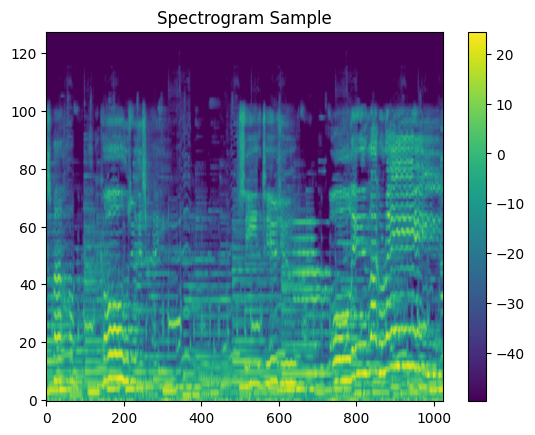

In [25]:
import matplotlib.pyplot as plt

spec = specs[0][0].numpy()

plt.imshow(spec, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Spectrogram Sample")
plt.show()